# Chapter 09: Spaces of Curvature Bounded Above

**Source Span.** Chapter 9, printed pages 307-350, PDF pages 322-365. The local `source_map.json` identifies four sections: 9.1 Definitions and Local Properties, 9.2 Hadamard Spaces, 9.3 Fundamental Group of a Nonpositively Curved Space, and 9.4 Example: Semi-dispersing Billiards. The PDF is used here only for chapter orientation, terminology, section order, and page spans; all exposition, examples, code, diagrams, checks, and artifacts are original.

## Chapter Question

How can an upper curvature bound be recognized from distances alone, and what does that bound buy us? In this chapter the answer is the CAT comparison inequality. A triangle in the space is tested against a triangle in a constant-curvature model; if points on the sides are never farther apart than their comparison points, the space bends no more positively than the model. That single metric inequality becomes a strong engine: local CAT(0) hypotheses globalize under simple connectedness, complete CAT(0) spaces have unique geodesics, and nonpositive curvature constrains fundamental groups through actions on the universal cover.

The notebook uses a computational translation: a geodesic triangle becomes side lengths plus sampled side points; a local condition becomes a link or proof-state diagram; a Hadamard space becomes a complete geodesic CAT(0) metric space with convex distance behavior; a fundamental-group statement becomes translations on a lifted tiling; and the billiard example becomes a reflection law with a numerical invariant.


## Library Routing

- **Matplotlib** draws durable 2D comparison diagrams, cube/tree local models, universal-cover pictures, and billiard reflection snapshots. These are metric diagrams where exact labels and equal aspect ratio matter more than interactive rendering.
- **NetworkX** records proof dependencies and finite geodesic checks. The chapter has several local-to-global implications, so graph structure is pedagogically useful rather than decorative.
- **Plotly** is used for the semi-dispersing billiard lab because a parameter sweep over impact height is the cleanest way to inspect how reflection changes outgoing directions while preserving speed.
- **NumPy and small exact formulas** handle distances, side interpolation, angle residuals, and artifact sanity checks. The computations are intentionally small enough to audit line by line.
- **JSON/CSV artifacts** record coverage, storyboard decisions, numeric invariants, and final sanity results so the visuals have a reproducible contract.


## Visual Storyboard

1. **CAT comparison inequality.** Build one Euclidean comparison triangle and one CAT(0)-friendly tree triangle with the same side lengths. Sample points on corresponding sides and verify the tree distance is no larger than the Euclidean comparison distance.
2. **Local properties and examples.** Show how trees and cube complexes package upper curvature: trees have unique arcs; cube complexes need local link data to prevent hidden positive curvature.
3. **Hadamard proof state.** Draw the dependency graph behind the local-to-global theorem and the consequences of being a Hadamard space.
4. **Fundamental group in nonpositive curvature.** Lift a flat torus picture to the plane and interpret loops as deck translations acting on a CAT(0) universal cover.
5. **Semi-dispersing billiards.** Reflect rays from a convex obstacle, preserve speed, and vary the impact parameter in a standalone HTML lab.


In [1]:
from __future__ import annotations

import json
import math
import sys
from collections import deque
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
from PIL import Image as PILImage, ImageStat

BOOK_ROOT = Path.cwd()
for candidate in [BOOK_ROOT, *BOOK_ROOT.parents]:
    if (candidate / "AGENTS.md").exists() and (candidate / "artifacts").exists():
        BOOK_ROOT = candidate
        break
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, display_artifact, relative_to_book, save_csv, save_json, save_matplotlib, save_plotly_html

ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / "chapter-09"
FIG_DIR = ARTIFACT_ROOT / "figures"
HTML_DIR = ARTIFACT_ROOT / "html"
CHECK_DIR = ARTIFACT_ROOT / "checks"
TABLE_DIR = ARTIFACT_ROOT / "tables"
for directory in [FIG_DIR, HTML_DIR, CHECK_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

SOURCE_SECTIONS = [
    {"section": "9.1", "title": "Definitions and Local Properties", "printed_start": 308, "pdf_start": 323},
    {"section": "9.2", "title": "Hadamard Spaces", "printed_start": 324, "pdf_start": 339},
    {"section": "9.3", "title": "Fundamental Group of a Nonpositively Curved Space", "printed_start": 338, "pdf_start": 353},
    {"section": "9.4", "title": "Example: Semi-dispersing Billiards", "printed_start": 341, "pdf_start": 356},
]

source_coverage = {
    "chapter": 9,
    "title": "Spaces of Curvature Bounded Above",
    "printed_pages": "307-350",
    "pdf_pages": "322-365",
    "source_use": "orientation, section order, terminology, and coverage checks only",
    "sections": SOURCE_SECTIONS,
    "coverage_plan": [
        {"section": "9.1", "notebook_assets": ["cat-comparison-inequality.png", "cube-tree-link-examples.png"], "concepts": ["CAT(k) comparison", "local CAT(0)", "links", "geodesic uniqueness checks"]},
        {"section": "9.2", "notebook_assets": ["hadamard-proof-dependencies.png", "cat-comparison-checks.json"], "concepts": ["Hadamard space", "Cartan-Hadamard globalization", "convex distance", "unique geodesics"]},
        {"section": "9.3", "notebook_assets": ["fundamental-group-cover-action.png", "fundamental-group-checks.json"], "concepts": ["universal cover", "deck transformations", "nonpositive curvature constraints on loops"]},
        {"section": "9.4", "notebook_assets": ["semi-dispersing-billiard-reflection.png", "semi-dispersing-billiard-lab.html"], "concepts": ["convex scatterer", "reflection law", "speed preservation", "defocusing parameter sweep"]},
    ],
}
save_json(source_coverage, CHECK_DIR / "source-coverage.json")
save_csv(source_coverage["coverage_plan"], TABLE_DIR / "source-coverage.csv")
source_coverage


{'chapter': 9,
 'title': 'Spaces of Curvature Bounded Above',
 'printed_pages': '307-350',
 'pdf_pages': '322-365',
 'source_use': 'orientation, section order, terminology, and coverage checks only',
 'sections': [{'section': '9.1',
   'title': 'Definitions and Local Properties',
   'printed_start': 308,
   'pdf_start': 323},
  {'section': '9.2',
   'title': 'Hadamard Spaces',
   'printed_start': 324,
   'pdf_start': 339},
  {'section': '9.3',
   'title': 'Fundamental Group of a Nonpositively Curved Space',
   'printed_start': 338,
   'pdf_start': 353},
  {'section': '9.4',
   'title': 'Example: Semi-dispersing Billiards',
   'printed_start': 341,
   'pdf_start': 356}],
 'coverage_plan': [{'section': '9.1',
   'notebook_assets': ['cat-comparison-inequality.png',
    'cube-tree-link-examples.png'],
   'concepts': ['CAT(k) comparison',
    'local CAT(0)',
    'links',
    'geodesic uniqueness checks']},
  {'section': '9.2',
   'notebook_assets': ['hadamard-proof-dependencies.png',
    'c

## 9.1 CAT Comparison and Local Upper Curvature

For a real number `k`, the model surface `M_k` is the simply connected complete two-dimensional space of constant curvature `k`: Euclidean plane for `k=0`, a sphere of radius `1/sqrt(k)` for `k>0`, and a hyperbolic plane of curvature `k` for `k<0`. A geodesic triangle in a metric space is compared with a triangle in `M_k` having the same side lengths. The space is **CAT(k)** on the scale being tested when distances between points on the original triangle are bounded above by the corresponding distances in the model triangle.

The inequality is an upper curvature bound because positive curvature tends to make geodesics reconverge and can create fat triangles. CAT(0) spaces are at least as thin as Euclidean comparison triangles. The first diagram uses a metric tree as a toy CAT(0) space: every triangle in a tree is a tripod, so points on sides are pulled through a central branch point and become no farther apart than in the Euclidean comparison triangle.


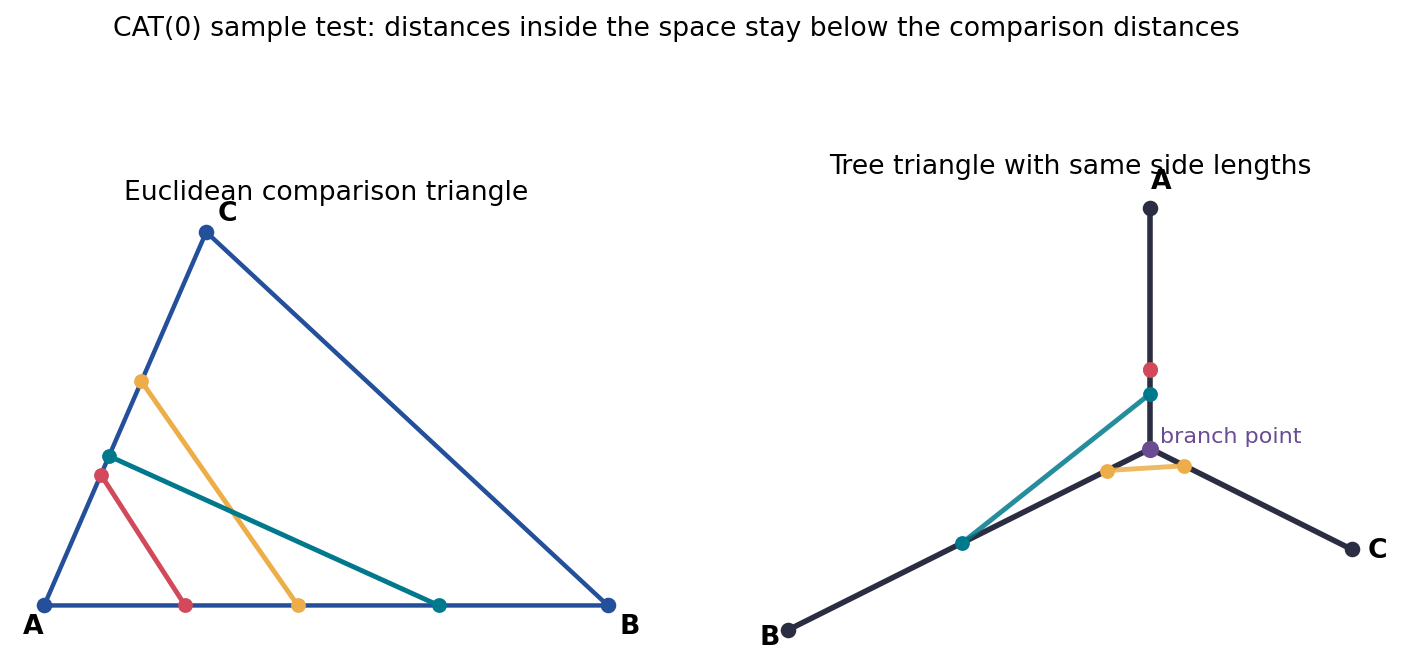

{'side_lengths': {'AB': 4.0,
  'AC': 2.8887713651308577,
  'BC': 3.8916577444580094},
 'tripod_branch_lengths': {'A': 1.498556810336424,
  'B': 2.5014431896635756,
  'C': 1.3902145547944338},
 'sample_count': 3,
 'samples': [{'t_on_AB': 0.25,
   's_on_AC': 0.35,
   'comparison_distance': 1.1032961977637736,
   'tree_distance': 0.011069977795800101,
   'slack': 1.0922262199679735},
  {'t_on_AB': 0.45,
   's_on_AC': 0.6,
   'comparison_distance': 1.9391235133430773,
   'tree_distance': 0.5361491984056668,
   'slack': 1.4029743149374105},
  {'t_on_AB': 0.7,
   's_on_AC': 0.4,
   'comparison_distance': 2.568890811225732,
   'tree_distance': 1.6444914539476567,
   'slack': 0.9243993572780753}],
 'all_cat0_inequalities_pass': True,
 'minimum_slack': 0.9243993572780753}

In [2]:
def euclidean_distance(p, q):
    return float(np.linalg.norm(np.asarray(p) - np.asarray(q)))


def point_on_segment(a, b, t):
    return (1 - t) * np.asarray(a) + t * np.asarray(b)


def tripod_branch_lengths(a, b, c):
    return {"A": (b + c - a) / 2, "B": (a + c - b) / 2, "C": (a + b - c) / 2}


def side_point_in_tripod(side, distance_from_first_endpoint, branches):
    first, second = side
    first_len = branches[first]
    if distance_from_first_endpoint <= first_len:
        return first, first_len - distance_from_first_endpoint
    return second, distance_from_first_endpoint - first_len


def tripod_distance(point_1, point_2):
    branch_1, radius_1 = point_1
    branch_2, radius_2 = point_2
    if branch_1 == branch_2:
        return abs(radius_1 - radius_2)
    return radius_1 + radius_2


A = np.array([0.0, 0.0])
B = np.array([4.0, 0.0])
C = np.array([1.15, 2.65])
a = euclidean_distance(B, C)
b = euclidean_distance(A, C)
c = euclidean_distance(A, B)
branches = tripod_branch_lengths(a, b, c)

samples = []
for t, s in [(0.25, 0.35), (0.45, 0.60), (0.70, 0.40)]:
    P_bar = point_on_segment(A, B, t)
    Q_bar = point_on_segment(A, C, s)
    euclidean_pq = euclidean_distance(P_bar, Q_bar)
    P_tree = side_point_in_tripod("AB", t * c, branches)
    Q_tree = side_point_in_tripod("AC", s * b, branches)
    tree_pq = tripod_distance(P_tree, Q_tree)
    samples.append({"t_on_AB": t, "s_on_AC": s, "comparison_distance": euclidean_pq, "tree_distance": tree_pq, "slack": euclidean_pq - tree_pq})

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
ax = axes[0]
triangle = np.vstack([A, B, C, A])
ax.plot(triangle[:, 0], triangle[:, 1], color="#234f9b", lw=2)
ax.scatter([A[0], B[0], C[0]], [A[1], B[1], C[1]], color="#234f9b", zorder=3)
for label, point, offset in [("A", A, (-0.15, -0.2)), ("B", B, (0.08, -0.2)), ("C", C, (0.08, 0.08))]:
    ax.text(point[0] + offset[0], point[1] + offset[1], label, fontsize=12, weight="bold")
for item, color in zip(samples, ["#d1495b", "#edae49", "#00798c"]):
    p = point_on_segment(A, B, item["t_on_AB"])
    q = point_on_segment(A, C, item["s_on_AC"])
    ax.plot([p[0], q[0]], [p[1], q[1]], color=color, lw=2.2)
    ax.scatter([p[0], q[0]], [p[1], q[1]], color=color, s=32, zorder=4)
ax.set_title("Euclidean comparison triangle")
ax.set_aspect("equal")
ax.axis("off")

ax = axes[1]
center = np.array([0.0, 0.0])
rays = {"A": np.array([0.0, 1.0]), "B": np.array([-0.9, -0.45]), "C": np.array([0.9, -0.45])}
coords = {name: center + length * rays[name] for name, length in branches.items()}
for name, endpoint in coords.items():
    ax.plot([0, endpoint[0]], [0, endpoint[1]], color="#2b2d42", lw=2.5)
    ax.scatter([endpoint[0]], [endpoint[1]], color="#2b2d42")
    ax.text(endpoint[0] * 1.08, endpoint[1] * 1.08, name, fontsize=12, weight="bold")
ax.scatter([0], [0], color="#6a4c93", s=45, zorder=5)
ax.text(0.06, 0.04, "branch point", color="#6a4c93")
for item, color in zip(samples, ["#d1495b", "#edae49", "#00798c"]):
    p = side_point_in_tripod("AB", item["t_on_AB"] * c, branches)
    q = side_point_in_tripod("AC", item["s_on_AC"] * b, branches)
    def locate(branch_point):
        branch, radius = branch_point
        return center + radius * rays[branch]
    pp = locate(p)
    qq = locate(q)
    ax.plot([pp[0], qq[0]], [pp[1], qq[1]], color=color, lw=2.2, alpha=0.85)
    ax.scatter([pp[0], qq[0]], [pp[1], qq[1]], color=color, s=32, zorder=4)
ax.set_title("Tree triangle with same side lengths")
ax.set_aspect("equal")
ax.axis("off")

fig.suptitle("CAT(0) sample test: distances inside the space stay below the comparison distances", y=1.02)
cat_fig = save_matplotlib(fig, FIG_DIR / "cat-comparison-inequality.png")
plt.close(fig)

cat_checks = {
    "side_lengths": {"AB": c, "AC": b, "BC": a},
    "tripod_branch_lengths": branches,
    "sample_count": len(samples),
    "samples": samples,
    "all_cat0_inequalities_pass": bool(all(item["tree_distance"] <= item["comparison_distance"] + 1e-10 for item in samples)),
    "minimum_slack": float(min(item["slack"] for item in samples)),
}
save_json(cat_checks, CHECK_DIR / "cat-comparison-checks.json")
display_artifact(cat_fig, width=900)
cat_checks


The check is intentionally modest: it does not prove the tree is CAT(0), but it demonstrates the shape of the definition. The important habit is to compare a distance measured in the candidate space with the model distance between matching side parameters. For `k>0`, the same logic is used inside the diameter scale where model comparison triangles exist uniquely; for `k<0`, the hyperbolic model replaces the Euclidean one and the comparison triangle becomes thinner.

Local CAT bounds are delicate because a small neighborhood can look correct while a global loop creates multiple geodesics or a short link creates concentrated positive curvature. The next artifact separates two friendly local models: metric trees and cube complexes.


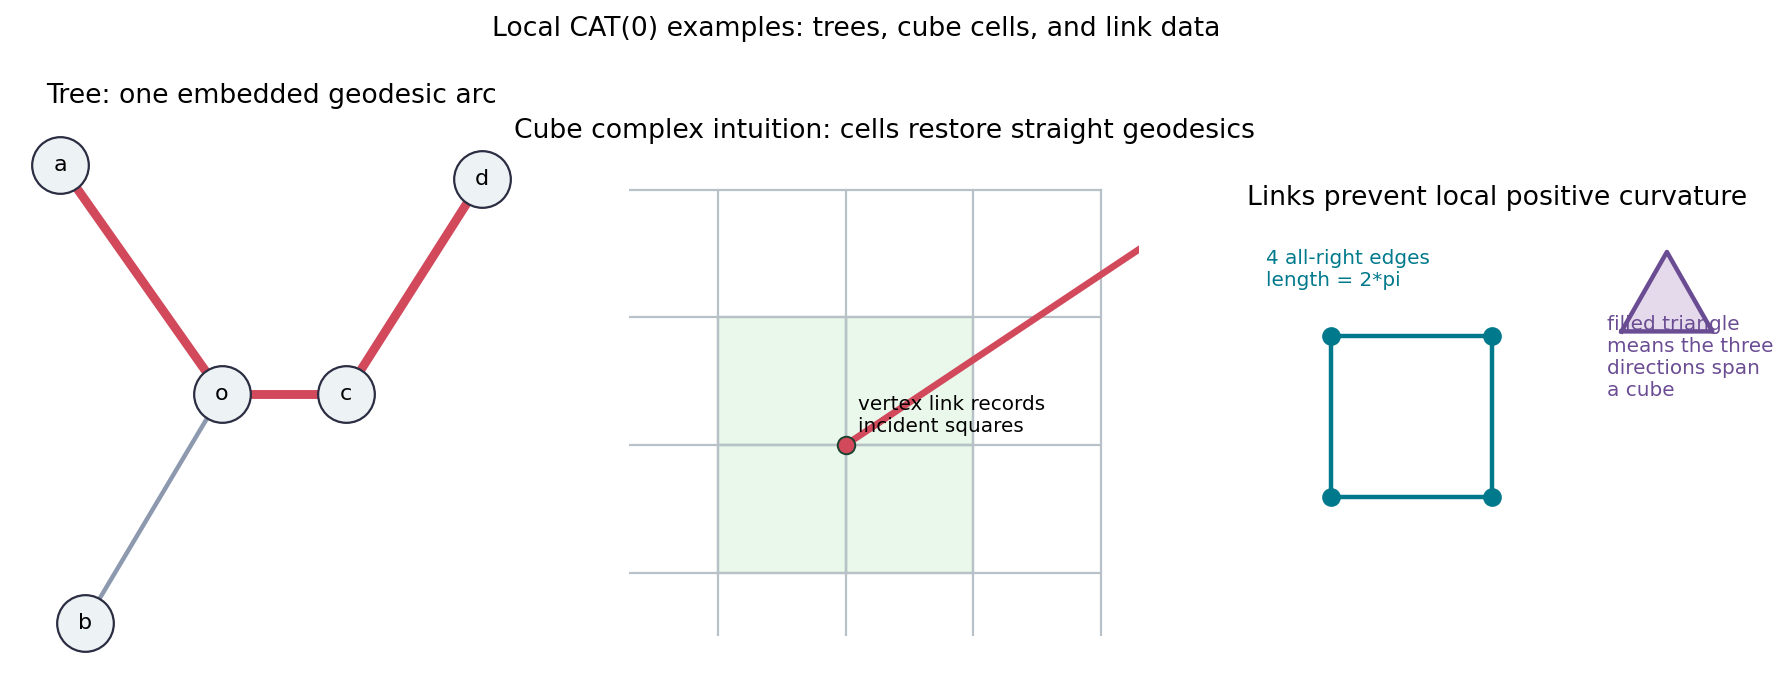

{'tree_shortest_path': ['a', 'o', 'c', 'd'],
 'tree_shortest_path_count_between_a_and_d': 1,
 'grid_endpoint_pair': [(0, 0), (3, 2)],
 'grid_combinatorial_shortest_path_count': 10,
 'grid_combinatorial_distance': 5,
 'straight_distance_inside_square_cells': 3.605551275463989,
 'link_cycle_length_for_four_right_angles': 6.283185307179586,
 'cat0_local_model_checks_pass': True}

In [3]:
def count_shortest_paths_grid(start, stop):
    dx = abs(stop[0] - start[0])
    dy = abs(stop[1] - start[1])
    return math.comb(dx + dy, dx)


T = nx.Graph()
T.add_edges_from([("o", "a"), ("o", "b"), ("o", "c"), ("c", "d")])
tree_path = nx.shortest_path(T, "a", "d")
unique_tree_paths = 0
queue = deque([("a", ["a"])])
while queue:
    node, path = queue.popleft()
    if node == "d":
        if len(path) - 1 == len(tree_path) - 1:
            unique_tree_paths += 1
        continue
    for nbr in T.neighbors(node):
        if nbr not in path and len(path) <= len(tree_path):
            queue.append((nbr, path + [nbr]))

grid_start = (0, 0)
grid_stop = (3, 2)
grid_shortest_count = count_shortest_paths_grid(grid_start, grid_stop)
straight_cell_distance = math.dist(grid_start, grid_stop)
combinatorial_distance = abs(grid_stop[0] - grid_start[0]) + abs(grid_stop[1] - grid_start[1])

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
ax = axes[0]
pos = {"o": (0, 0), "a": (-1.3, 0.8), "b": (-1.1, -0.8), "c": (1.0, 0), "d": (2.1, 0.75)}
nx.draw_networkx_edges(T, pos, ax=ax, width=2, edge_color="#8d99ae")
nx.draw_networkx_edges(T, pos, edgelist=list(zip(tree_path, tree_path[1:])), ax=ax, width=4, edge_color="#d1495b")
nx.draw_networkx_nodes(T, pos, ax=ax, node_color="#edf2f4", edgecolors="#2b2d42", node_size=650)
nx.draw_networkx_labels(T, pos, ax=ax, font_size=10)
ax.set_title("Tree: one embedded geodesic arc")
ax.axis("off")

ax = axes[1]
for x in range(-2, 3):
    ax.plot([x, x], [-2, 2], color="#b8c0c8", lw=1)
for y in range(-2, 3):
    ax.plot([-2, 2], [y, y], color="#b8c0c8", lw=1)
for quadrant in [(0, 0), (-1, 0), (0, -1), (-1, -1)]:
    ax.add_patch(plt.Rectangle(quadrant, 1, 1, facecolor="#d8f3dc", edgecolor="#40916c", alpha=0.55))
ax.scatter([0], [0], color="#1b4332", s=60, zorder=5)
ax.text(0.1, 0.1, "vertex link records\nincident squares", fontsize=9)
ax.plot([grid_start[0], grid_stop[0]], [grid_start[1], grid_stop[1]], color="#d1495b", lw=3)
ax.scatter([grid_start[0], grid_stop[0]], [grid_start[1], grid_stop[1]], color="#d1495b", zorder=6)
ax.set_xlim(-1.7, 2.3)
ax.set_ylim(-1.5, 2.3)
ax.set_aspect("equal")
ax.set_title("Cube complex intuition: cells restore straight geodesics")
ax.axis("off")

ax = axes[2]
angles = np.linspace(0, 2 * np.pi, 5)[:-1] + np.pi / 4
link_pts = np.c_[np.cos(angles), np.sin(angles)]
for i in range(4):
    j = (i + 1) % 4
    ax.plot([link_pts[i, 0], link_pts[j, 0]], [link_pts[i, 1], link_pts[j, 1]], color="#00798c", lw=2)
ax.scatter(link_pts[:, 0], link_pts[:, 1], color="#00798c", s=55)
ax.text(-1.28, 1.15, "4 all-right edges\nlength = 2*pi", fontsize=9, color="#00798c")
tri = np.array([[1.85, 0.75], [2.65, 0.75], [2.25, 1.45], [1.85, 0.75]])
ax.plot(tri[:, 0], tri[:, 1], color="#6a4c93", lw=2)
ax.fill(tri[:-1, 0], tri[:-1, 1], color="#cdb4db", alpha=0.5)
ax.text(1.72, 0.18, "filled triangle\nmeans the three\ndirections span\na cube", fontsize=9, color="#6a4c93")
ax.set_xlim(-1.5, 3.0)
ax.set_ylim(-1.35, 1.75)
ax.set_aspect("equal")
ax.set_title("Links prevent local positive curvature")
ax.axis("off")

fig.suptitle("Local CAT(0) examples: trees, cube cells, and link data", y=1.02)
examples_fig = save_matplotlib(fig, FIG_DIR / "cube-tree-link-examples.png")
plt.close(fig)

local_checks = {
    "tree_shortest_path": tree_path,
    "tree_shortest_path_count_between_a_and_d": unique_tree_paths,
    "grid_endpoint_pair": [grid_start, grid_stop],
    "grid_combinatorial_shortest_path_count": grid_shortest_count,
    "grid_combinatorial_distance": combinatorial_distance,
    "straight_distance_inside_square_cells": straight_cell_distance,
    "link_cycle_length_for_four_right_angles": float(2 * math.pi),
    "cat0_local_model_checks_pass": bool(unique_tree_paths == 1 and straight_cell_distance < combinatorial_distance and abs(2 * math.pi - sum([math.pi / 2] * 4)) < 1e-12),
}
save_json(local_checks, CHECK_DIR / "local-cube-tree-checks.json")
display_artifact(examples_fig, width=920)
local_checks


A metric tree is CAT(0) for a blunt reason: there is only one arc between two points, and every triangle collapses to a tripod. Cube complexes need a local diagnostic. Around a vertex, the link remembers which coordinate directions are allowed to meet. The all-right geometry of the link rules out short closed circuits that would behave like positive curvature concentrated at the vertex. In the square grid, many combinatorial edge paths can be shortest in the graph metric, but once the squares are filled in as Euclidean cells, the actual geodesic is the straight segment.

That distinction is central for the chapter: CAT geometry is a metric condition, not a drawing style. The same cell complex can tell different stories depending on whether we measure only along edges or through the cells.


## 9.2 Hadamard Spaces and the Local-to-Global Pattern

A **Hadamard space** is a complete geodesic CAT(0) space. The analogy with classical Riemannian Hadamard manifolds is deliberate: nonpositive curvature plus simple connectedness removes the global ambiguity in geodesics. The proof pattern in the chapter is a local-to-global machine. Local CAT(0) gives thin triangles in small balls; completeness prevents minimizing sequences from escaping; simple connectedness kills monodromy around loops; the conclusion is global CAT(0), and then uniqueness and convexity follow.

The graph below is not a proof by itself. It is a proof-state map: every arrow marks a dependency that must be supplied by a theorem or construction. This is useful because learners often remember the slogan but forget which hypothesis does which job.


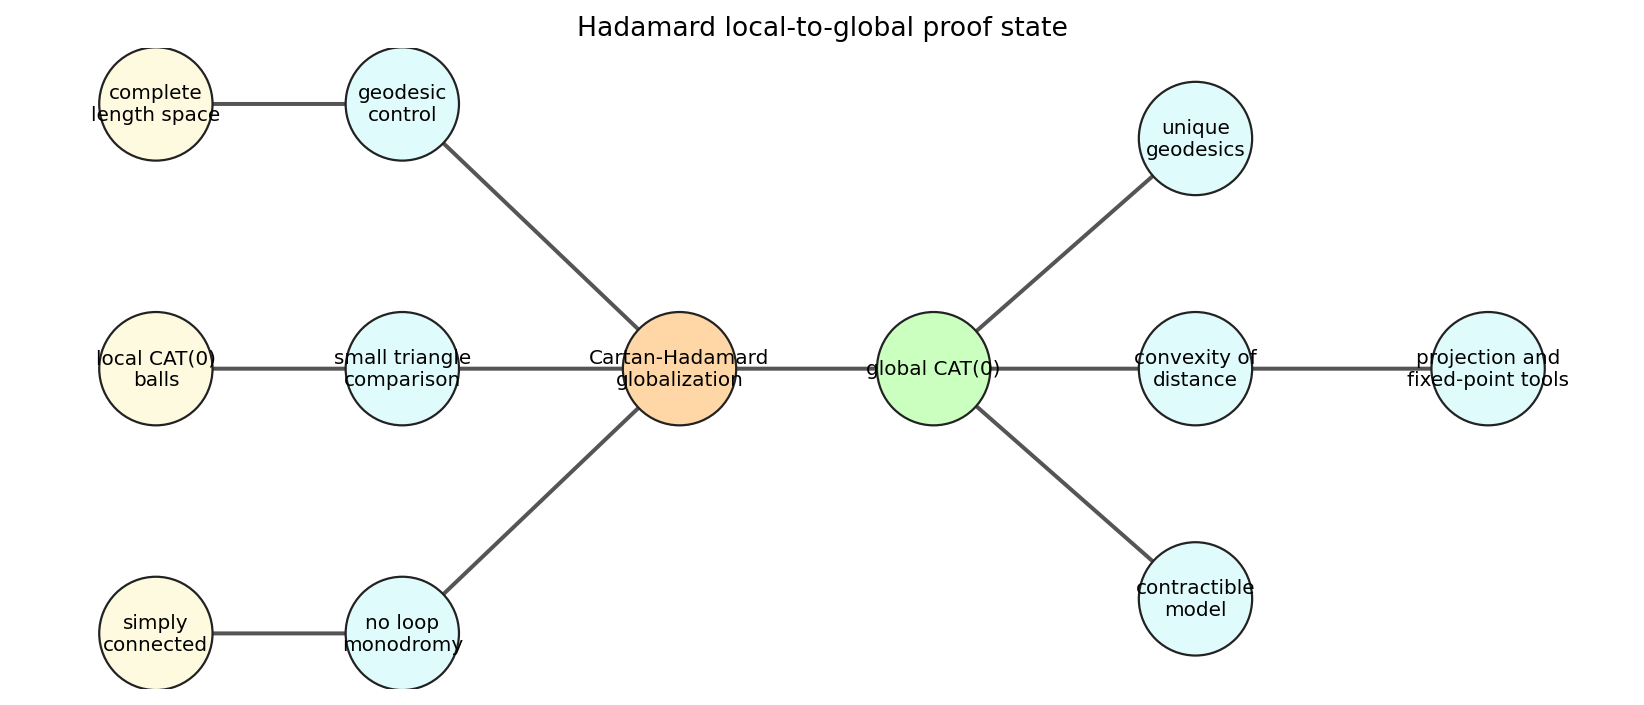

{'proof_graph_nodes': 12,
 'proof_graph_edges': 11,
 'convexity_sample_distances': [2.23606797749979,
  2.0854016399725017,
  1.937937047481161,
  1.7944637081869335,
  1.6560193235587561,
  1.523975065412817,
  1.4001428498549708,
  1.2868954891520907,
  1.1872657663724664,
  1.104943437466371,
  1.044030650891055,
  1.0084145972763385,
  1.0007996802557444,
  1.0218121158021176,
  1.0697663296253066,
  1.1412712210513327,
  1.2322337440599493,
  1.3386933928274989,
  1.4572576985557497,
  1.5852129194527782,
  1.7204650534085253],
 'minimum_discrete_second_difference': 0.00320174503594739,
 'euclidean_convexity_shadow_pass': True}

In [4]:
G = nx.DiGraph()
edges = [
    ("complete\nlength space", "geodesic\ncontrol"),
    ("local CAT(0)\nballs", "small triangle\ncomparison"),
    ("simply\nconnected", "no loop\nmonodromy"),
    ("geodesic\ncontrol", "Cartan-Hadamard\nglobalization"),
    ("small triangle\ncomparison", "Cartan-Hadamard\nglobalization"),
    ("no loop\nmonodromy", "Cartan-Hadamard\nglobalization"),
    ("Cartan-Hadamard\nglobalization", "global CAT(0)"),
    ("global CAT(0)", "unique\ngeodesics"),
    ("global CAT(0)", "convexity of\ndistance"),
    ("global CAT(0)", "contractible\nmodel"),
    ("convexity of\ndistance", "projection and\nfixed-point tools"),
]
G.add_edges_from(edges)
pos = {
    "complete\nlength space": (-2.4, 1.4),
    "local CAT(0)\nballs": (-2.4, 0.25),
    "simply\nconnected": (-2.4, -0.9),
    "geodesic\ncontrol": (-0.8, 1.4),
    "small triangle\ncomparison": (-0.8, 0.25),
    "no loop\nmonodromy": (-0.8, -0.9),
    "Cartan-Hadamard\nglobalization": (1.0, 0.25),
    "global CAT(0)": (2.65, 0.25),
    "unique\ngeodesics": (4.35, 1.25),
    "convexity of\ndistance": (4.35, 0.25),
    "contractible\nmodel": (4.35, -0.75),
    "projection and\nfixed-point tools": (6.25, 0.25),
}
fig, ax = plt.subplots(figsize=(13, 5.2))
node_colors = []
for node in G.nodes:
    if node in {"complete\nlength space", "local CAT(0)\nballs", "simply\nconnected"}:
        node_colors.append("#fefae0")
    elif node == "Cartan-Hadamard\nglobalization":
        node_colors.append("#ffd6a5")
    elif node == "global CAT(0)":
        node_colors.append("#caffbf")
    else:
        node_colors.append("#e0fbfc")
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=18, width=1.8, edge_color="#555")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, edgecolors="#222", node_size=2600)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9)
ax.set_title("Hadamard local-to-global proof state")
ax.axis("off")
hadamard_fig = save_matplotlib(fig, FIG_DIR / "hadamard-proof-dependencies.png")
plt.close(fig)

P0 = np.array([-1.0, 0.0])
P1 = np.array([2.0, 1.0])
Q0 = np.array([0.0, 2.0])
Q1 = np.array([3.0, -0.4])
ts = np.linspace(0, 1, 21)
distances = [euclidean_distance(point_on_segment(P0, P1, t), point_on_segment(Q0, Q1, t)) for t in ts]
second_differences = np.diff(distances, n=2)
hadamard_checks = {
    "proof_graph_nodes": G.number_of_nodes(),
    "proof_graph_edges": G.number_of_edges(),
    "convexity_sample_distances": [float(x) for x in distances],
    "minimum_discrete_second_difference": float(second_differences.min()),
    "euclidean_convexity_shadow_pass": bool(second_differences.min() >= -5e-3),
}
save_json(hadamard_checks, CHECK_DIR / "hadamard-checks.json")
display_artifact(hadamard_fig, width=930)
hadamard_checks


The convexity check samples a Euclidean shadow of the CAT(0) consequence: if two geodesics are traversed at the same speed, the distance between corresponding points behaves convexly. In a general Hadamard space the theorem is metric rather than linear, but the computational habit is the same: sample a statement that should become easier, not harder, as the parameter moves through the geodesic.


## 9.3 Fundamental Groups of Nonpositively Curved Spaces

Nonpositive curvature becomes algebraic when we pass to the universal cover. If a compact or well-controlled space is locally CAT(0), its universal cover is CAT(0) under the Cartan-Hadamard theorem. The fundamental group acts on that cover by deck transformations. A loop downstairs becomes a displacement upstairs.

The flat torus is the cleanest finite picture. Downstairs, a horizontal loop closes. Upstairs in the plane, the lifted path starts in one fundamental square and ends one translated square away. The group element is the translation vector. More complicated nonpositively curved spaces use the same idea: study the group by how it moves points in a CAT(0) cover.


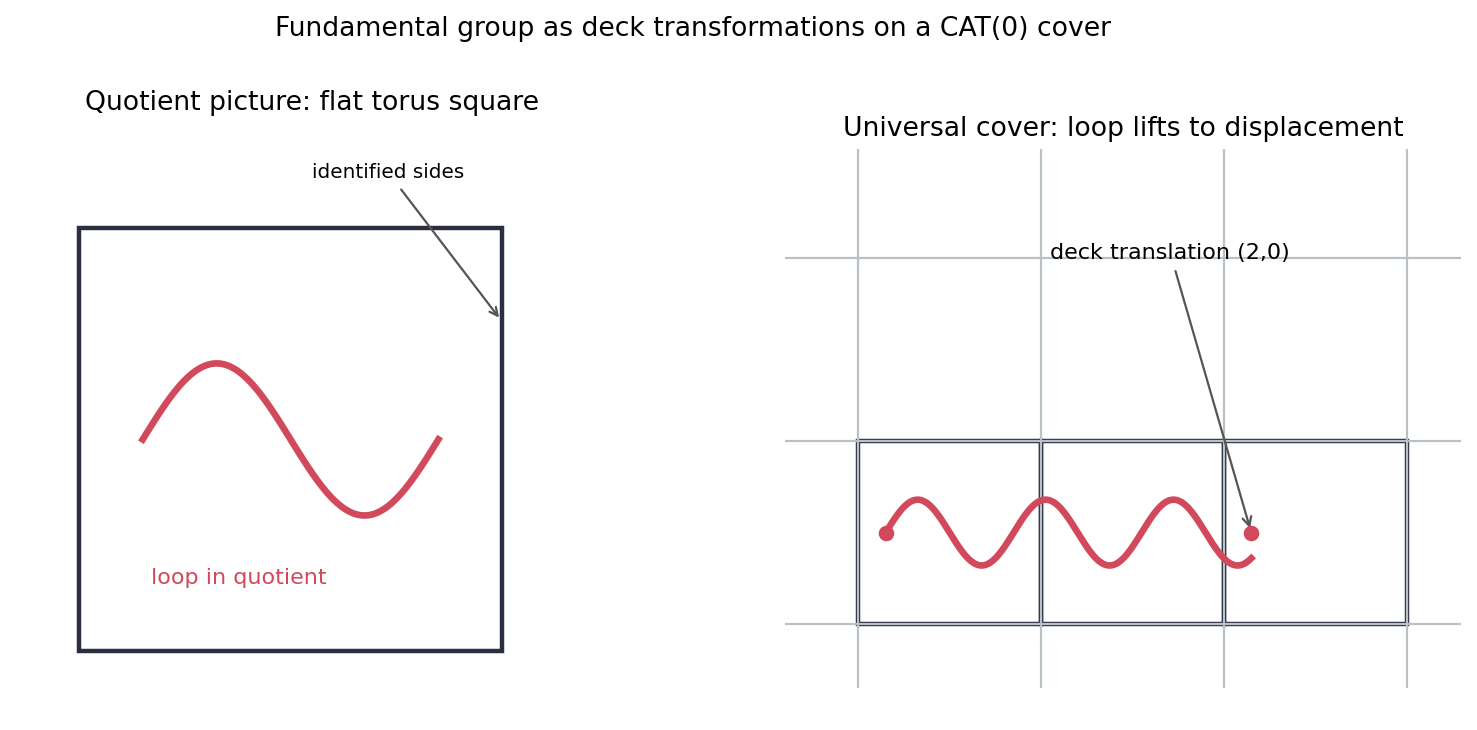

{'example_group': 'Z^2 deck translations of the Euclidean cover of a flat torus',
 'commutator_residual_for_two_translations': 0.0,
 'translation_lengths': {'(2,0)': 2.0, '(0,1)': 1.0, '(0,0)': 0.0},
 'nontrivial_translation_has_positive_displacement': True}

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ax = axes[0]
ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=False, edgecolor="#2b2d42", lw=2))
loop_x = np.linspace(0.15, 0.85, 120)
loop_y = 0.5 + 0.18 * np.sin(2 * np.pi * (loop_x - 0.15) / 0.70)
ax.plot(loop_x, loop_y, color="#d1495b", lw=3)
ax.annotate("identified sides", xy=(1.0, 0.78), xytext=(0.55, 1.12), arrowprops=dict(arrowstyle="->", color="#555"), fontsize=9)
ax.text(0.17, 0.16, "loop in quotient", color="#d1495b", fontsize=10)
ax.set_xlim(-0.15, 1.25)
ax.set_ylim(-0.15, 1.25)
ax.set_aspect("equal")
ax.set_title("Quotient picture: flat torus square")
ax.axis("off")

ax = axes[1]
for x in range(-1, 4):
    ax.plot([x, x], [-1, 3], color="#b8c0c8", lw=1)
for y in range(-1, 4):
    ax.plot([-1, 4], [y, y], color="#b8c0c8", lw=1)
for shift in [(0, 0), (1, 0), (2, 0)]:
    ax.add_patch(plt.Rectangle(shift, 1, 1, fill=False, edgecolor="#2b2d42", lw=2))
start = np.array([0.15, 0.5])
end = start + np.array([2.0, 0.0])
path_x = np.linspace(start[0], end[0], 200)
path_y = 0.5 + 0.18 * np.sin(2 * np.pi * (path_x - start[0]) / 0.70)
ax.plot(path_x, path_y, color="#d1495b", lw=3)
ax.scatter([start[0], end[0]], [start[1], end[1]], color="#d1495b", zorder=5)
ax.annotate("deck translation (2,0)", xy=(end[0], end[1]), xytext=(1.05, 2.0), arrowprops=dict(arrowstyle="->", color="#555"), fontsize=10)
ax.set_xlim(-0.4, 3.3)
ax.set_ylim(-0.35, 2.6)
ax.set_aspect("equal")
ax.set_title("Universal cover: loop lifts to displacement")
ax.axis("off")

fig.suptitle("Fundamental group as deck transformations on a CAT(0) cover", y=1.02)
cover_fig = save_matplotlib(fig, FIG_DIR / "fundamental-group-cover-action.png")
plt.close(fig)

u = np.array([2, 0])
v = np.array([0, 1])
commutator_residual = np.linalg.norm((u + v - u - v).astype(float))
translation_lengths = {"(2,0)": float(np.linalg.norm(u)), "(0,1)": float(np.linalg.norm(v)), "(0,0)": 0.0}
fundamental_group_checks = {
    "example_group": "Z^2 deck translations of the Euclidean cover of a flat torus",
    "commutator_residual_for_two_translations": float(commutator_residual),
    "translation_lengths": translation_lengths,
    "nontrivial_translation_has_positive_displacement": bool(all(length > 0 for name, length in translation_lengths.items() if name != "(0,0)")),
}
save_json(fundamental_group_checks, CHECK_DIR / "fundamental-group-checks.json")
display_artifact(cover_fig, width=900)
fundamental_group_checks


The torus is not meant to stand for every nonpositively curved group. It is a calibration example: the universal cover is visible, the action is by isometries, and a group element has a measurable displacement. In richer CAT(0) spaces, this displacement viewpoint leads to restrictions on torsion, splitting behavior, and fixed-point phenomena. The chapter's moral is that curvature bounds can turn questions about loops into questions about isometric group actions.


## 9.4 Semi-Dispersing Billiards as a CAT-Style Example

Semi-dispersing billiards enter the chapter as a geometric example where the ambient motion is flat between collisions but the boundary geometry matters. At a collision with a convex scatterer, the velocity reflects by reversing the normal component and preserving the tangential component. Speed is preserved exactly; nearby rays tend to separate after reflection from convex obstacles, which is the dispersing intuition.

The lab below uses a circular scatterer. A horizontal ray with impact height `b` hits the circle, reflects according to `v_out = v_in - 2 <v_in,n> n`, and then continues. The static figure shows several impact heights; the HTML artifact lets the learner sweep the parameter.


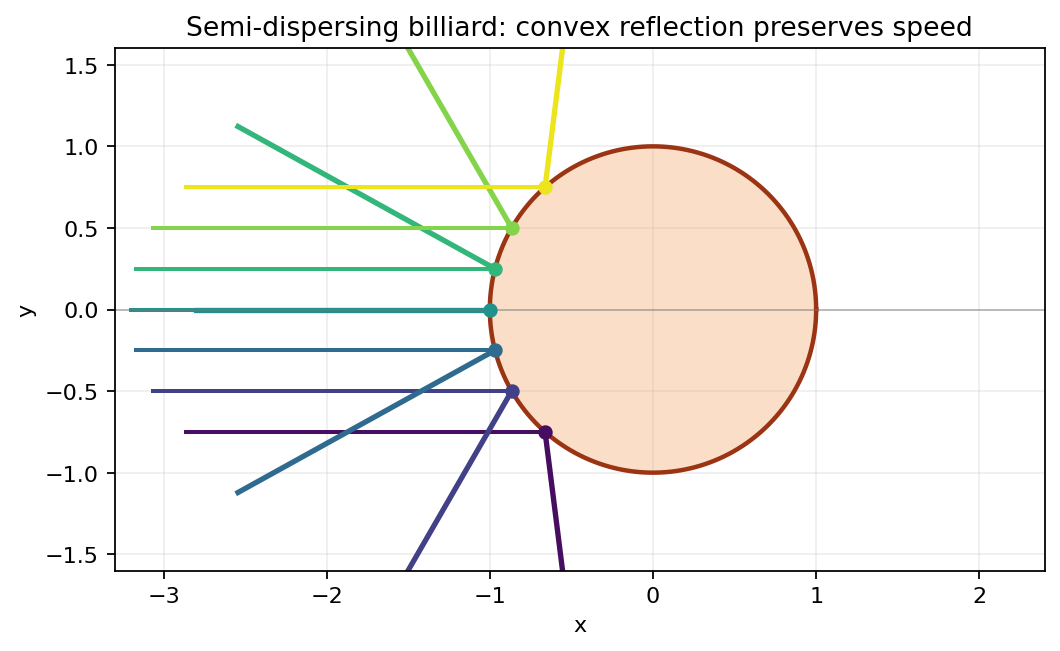

D:\Geometry\.venv\Lib\site-packages\IPython\core\display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


{'impact_values': [-0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75],
 'max_speed_residual': 2.220446049250313e-16,
 'max_angle_residual': 3.3306690738754696e-16,
 'outgoing_angles': [-1.4454684956268313,
  -2.0943951023931957,
  -2.636232143305636,
  3.141592653589793,
  2.636232143305636,
  2.0943951023931957,
  1.4454684956268313],
 'outgoing_angle_increases_with_impact_height': False,
 'reflection_law_checks_pass': True}

In [6]:
def reflect_from_unit_circle(impact_height):
    b = float(impact_height)
    if abs(b) >= 1:
        raise ValueError("impact height must be strictly inside the unit circle")
    hit = np.array([-math.sqrt(1 - b * b), b])
    incoming = np.array([1.0, 0.0])
    normal = hit / np.linalg.norm(hit)
    outgoing = incoming - 2 * np.dot(incoming, normal) * normal
    speed_residual = abs(np.linalg.norm(outgoing) - np.linalg.norm(incoming))
    incidence_cos = abs(np.dot(-incoming, normal))
    reflection_cos = abs(np.dot(outgoing, normal))
    angle_residual = abs(incidence_cos - reflection_cos)
    return {"b": b, "hit": hit, "incoming": incoming, "normal": normal, "outgoing": outgoing, "speed_residual": speed_residual, "angle_residual": angle_residual, "outgoing_angle": math.atan2(outgoing[1], outgoing[0])}


impact_values = np.linspace(-0.75, 0.75, 7)
reflections = [reflect_from_unit_circle(b) for b in impact_values]

fig, ax = plt.subplots(figsize=(7.5, 6.2))
theta = np.linspace(0, 2 * np.pi, 400)
ax.fill(np.cos(theta), np.sin(theta), color="#f4a261", alpha=0.35, label="convex scatterer")
ax.plot(np.cos(theta), np.sin(theta), color="#9a3412", lw=2)
for item in reflections:
    hit = item["hit"]
    incoming_start = hit - 2.2 * item["incoming"]
    outgoing_end = hit + 1.8 * item["outgoing"]
    color = plt.cm.viridis((item["b"] + 0.8) / 1.6)
    ax.plot([incoming_start[0], hit[0]], [incoming_start[1], hit[1]], color=color, lw=1.8)
    ax.plot([hit[0], outgoing_end[0]], [hit[1], outgoing_end[1]], color=color, lw=2.4)
    ax.scatter([hit[0]], [hit[1]], color=color, s=30, zorder=5)
ax.axhline(0, color="#777", lw=0.8, alpha=0.5)
ax.set_aspect("equal")
ax.set_xlim(-3.3, 2.4)
ax.set_ylim(-1.6, 1.6)
ax.set_title("Semi-dispersing billiard: convex reflection preserves speed")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(alpha=0.2)
billiard_fig = save_matplotlib(fig, FIG_DIR / "semi-dispersing-billiard-reflection.png")
plt.close(fig)

frames = []
slider_steps = []
html_b_values = np.linspace(-0.85, 0.85, 35)
base_circle = go.Scatter(x=np.cos(theta), y=np.sin(theta), mode="lines", line=dict(color="#9a3412", width=3), fill="toself", fillcolor="rgba(244,162,97,0.28)", name="scatterer")
for idx, bval in enumerate(html_b_values):
    item = reflect_from_unit_circle(bval)
    hit = item["hit"]
    incoming_start = hit - 2.4 * item["incoming"]
    outgoing_end = hit + 2.1 * item["outgoing"]
    data = [
        base_circle,
        go.Scatter(x=[incoming_start[0], hit[0]], y=[incoming_start[1], hit[1]], mode="lines", line=dict(color="#264653", width=4), name="incoming"),
        go.Scatter(x=[hit[0], outgoing_end[0]], y=[hit[1], outgoing_end[1]], mode="lines", line=dict(color="#e76f51", width=4), name="reflected"),
        go.Scatter(x=[hit[0]], y=[hit[1]], mode="markers", marker=dict(color="#e76f51", size=10), name="collision"),
    ]
    frames.append(go.Frame(data=data, name=f"{idx}"))
    slider_steps.append({"args": [[f"{idx}"], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}], "label": f"{bval:.2f}", "method": "animate"})

fig_html = go.Figure(data=frames[17].data, frames=frames)
fig_html.update_layout(
    title="Semi-dispersing billiard reflection lab: impact height b",
    xaxis=dict(range=[-3.4, 2.5], scaleanchor="y", scaleratio=1, zeroline=False),
    yaxis=dict(range=[-1.75, 1.75], zeroline=False),
    width=820,
    height=520,
    margin=dict(l=40, r=20, t=60, b=55),
    sliders=[{"active": 17, "currentvalue": {"prefix": "b = "}, "steps": slider_steps}],
    showlegend=False,
)
billiard_html = save_plotly_html(fig_html, HTML_DIR / "semi-dispersing-billiard-lab.html")

angles = np.array([item["outgoing_angle"] for item in reflections])
billiard_checks = {
    "impact_values": [float(x) for x in impact_values],
    "max_speed_residual": float(max(item["speed_residual"] for item in reflections)),
    "max_angle_residual": float(max(item["angle_residual"] for item in reflections)),
    "outgoing_angles": [float(x) for x in angles],
    "outgoing_angle_increases_with_impact_height": bool(np.all(np.diff(angles) > 0)),
    "reflection_law_checks_pass": bool(max(item["speed_residual"] for item in reflections) < 1e-12 and max(item["angle_residual"] for item in reflections) < 1e-12),
}
save_json(billiard_checks, CHECK_DIR / "billiard-reflection-checks.json")
display_artifact(billiard_fig, width=760)
display_artifact(billiard_html, width=860, height=560)
billiard_checks


The reflection law is the invariant part of the billiard model: speed and equal-angle reflection survive every allowed collision. The monotone outgoing angle in this circular example is a parameter-lab proxy for dispersing behavior. A full billiard table is more subtle because repeated collisions create a piecewise-geodesic flow with singular grazing directions, but the local geometric mechanism is already visible in the one-obstacle reflection.


## Applied Lab

Use the billiard HTML artifact as a small experiment. Sweep the impact height from negative to positive values and watch three quantities: the collision point on the convex boundary, the outgoing direction, and the fact that ray length per unit time is unchanged by reflection. Then compare that lab with the CAT comparison figure. Both are metric stories, but they put the metric pressure in different places: CAT(0) controls triangles globally or locally, while the billiard example controls how straight motion is folded by a convex boundary.

A productive extension is to replace the circular obstacle by an ellipse and rerun the reflection residuals. Speed preservation should survive because it is built into the reflection formula. Monotonic defocusing can become more sensitive because curvature varies along the boundary.


## Final Sanity Checks and Source Coverage Contract

The final cell checks three kinds of promises. First, every displayed artifact exists and has nontrivial size. Second, the numerical invariants attached to the chapter concepts pass: CAT sample inequalities, local tree/cube checks, Hadamard proof graph construction, deck-translation checks, and billiard reflection residuals. Third, the source coverage JSON names all four mapped sections and connects each to a notebook asset.


In [7]:
visual_storyboard = {
    "chapter": 9,
    "storyboard_items": [
        {"concept": "CAT comparison inequality", "representation": "Euclidean triangle paired with tree tripod", "artifact": relative_to_book(cat_fig, BOOK_ROOT), "check": "tree side-point distances do not exceed Euclidean comparison distances"},
        {"concept": "local CAT(0) examples", "representation": "tree path, square cells, and all-right link data", "artifact": relative_to_book(examples_fig, BOOK_ROOT), "check": "unique tree path and link-angle diagnostics"},
        {"concept": "Hadamard local-to-global theorem", "representation": "NetworkX dependency graph", "artifact": relative_to_book(hadamard_fig, BOOK_ROOT), "check": "proof graph and convexity shadow"},
        {"concept": "fundamental group of NPC spaces", "representation": "covering-space translation diagram", "artifact": relative_to_book(cover_fig, BOOK_ROOT), "check": "deck translations commute in the torus calibration example and nontrivial translations displace points"},
        {"concept": "semi-dispersing billiards", "representation": "reflection snapshot plus Plotly impact-height lab", "artifact": relative_to_book(billiard_fig, BOOK_ROOT), "check": "speed and reflection-angle residuals vanish numerically"},
    ],
    "library_routing": {"matplotlib": "metric diagrams", "networkx": "proof and finite path checks", "plotly": "billiard parameter lab", "json_csv": "coverage and invariant records"},
}
save_json(visual_storyboard, CHECK_DIR / "visual-storyboard.json")

artifact_paths = [
    cat_fig,
    examples_fig,
    hadamard_fig,
    cover_fig,
    billiard_fig,
    billiard_html,
    CHECK_DIR / "source-coverage.json",
    CHECK_DIR / "visual-storyboard.json",
    CHECK_DIR / "cat-comparison-checks.json",
    CHECK_DIR / "local-cube-tree-checks.json",
    CHECK_DIR / "hadamard-checks.json",
    CHECK_DIR / "fundamental-group-checks.json",
    CHECK_DIR / "billiard-reflection-checks.json",
    TABLE_DIR / "source-coverage.csv",
]
assert_artifacts(artifact_paths, min_bytes=80)


def png_stats(path):
    with PILImage.open(path) as img:
        img.load()
        stat = ImageStat.Stat(img.convert("RGB"))
        return {"width": img.width, "height": img.height, "max_channel_stddev": float(max(stat.stddev))}


png_diagnostics = {relative_to_book(path, BOOK_ROOT): png_stats(path) for path in [cat_fig, examples_fig, hadamard_fig, cover_fig, billiard_fig]}
for stats in png_diagnostics.values():
    assert stats["width"] >= 400 and stats["height"] >= 250
    assert stats["max_channel_stddev"] > 1.0

coverage_sections = {item["section"] for item in source_coverage["sections"]}
expected_sections = {"9.1", "9.2", "9.3", "9.4"}

final_sanity = {
    "chapter": 9,
    "artifact_count": len(artifact_paths),
    "artifacts": [{"path": relative_to_book(path, BOOK_ROOT), "bytes": path.stat().st_size} for path in artifact_paths],
    "png_diagnostics": png_diagnostics,
    "checks": {
        "source_sections_covered": sorted(coverage_sections),
        "all_source_sections_present": coverage_sections == expected_sections,
        "cat0_sample_inequalities_pass": cat_checks["all_cat0_inequalities_pass"],
        "local_cube_tree_checks_pass": local_checks["cat0_local_model_checks_pass"],
        "hadamard_convexity_shadow_pass": hadamard_checks["euclidean_convexity_shadow_pass"],
        "fundamental_group_translation_checks_pass": fundamental_group_checks["nontrivial_translation_has_positive_displacement"],
        "billiard_reflection_law_checks_pass": billiard_checks["reflection_law_checks_pass"],
    },
    "pdf_source_span": "PDF pages 322-365; printed pages 307-350",
    "copyright_note": "No copied source prose, exercises, screenshots, page crops, or figures are used.",
}
save_json(final_sanity, CHECK_DIR / "final-sanity.json")

assert final_sanity["checks"]["all_source_sections_present"]
assert final_sanity["checks"]["cat0_sample_inequalities_pass"]
assert final_sanity["checks"]["local_cube_tree_checks_pass"]
assert final_sanity["checks"]["hadamard_convexity_shadow_pass"]
assert final_sanity["checks"]["fundamental_group_translation_checks_pass"]
assert final_sanity["checks"]["billiard_reflection_law_checks_pass"]
final_sanity


{'chapter': 9,
 'artifact_count': 14,
 'artifacts': [{'path': 'artifacts/chapter-09/figures/cat-comparison-inequality.png',
   'bytes': 72735},
  {'path': 'artifacts/chapter-09/figures/cube-tree-link-examples.png',
   'bytes': 90106},
  {'path': 'artifacts/chapter-09/figures/hadamard-proof-dependencies.png',
   'bytes': 126099},
  {'path': 'artifacts/chapter-09/figures/fundamental-group-cover-action.png',
   'bytes': 62868},
  {'path': 'artifacts/chapter-09/figures/semi-dispersing-billiard-reflection.png',
   'bytes': 58696},
  {'path': 'artifacts/chapter-09/html/semi-dispersing-billiard-lab.html',
   'bytes': 430363},
  {'path': 'artifacts/chapter-09/checks/source-coverage.json', 'bytes': 2102},
  {'path': 'artifacts/chapter-09/checks/visual-storyboard.json',
   'bytes': 1739},
  {'path': 'artifacts/chapter-09/checks/cat-comparison-checks.json',
   'bytes': 929},
  {'path': 'artifacts/chapter-09/checks/local-cube-tree-checks.json',
   'bytes': 482},
  {'path': 'artifacts/chapter-09/ch

## Takeaways

- CAT(k) is a distance comparison rule for geodesic triangles: side-point distances in the space must be no larger than in the constant-curvature model.
- CAT(0) examples can be extremely nonsmooth. Trees, square grids, and cube complexes are natural because the definition only asks for metric comparison, not differentiability.
- Local upper curvature bounds need global hypotheses. Completeness and simple connectedness are the bridge from local CAT(0) data to Hadamard behavior.
- In a Hadamard space, geodesics are unique and distance functions behave convexly enough to support projection, fixed-point, and group-action arguments.
- For nonpositively curved spaces, the fundamental group is best inspected upstairs: loops lift to deck transformations of a CAT(0) universal cover.
- Semi-dispersing billiards combine flat motion with convex reflections; the local reflection law preserves speed while the boundary geometry drives the qualitative dynamics.
